In [1]:
!pip install pandas numpy seaborn matplotlib scikit-learn glob2 xgboost

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.metrics import accuracy_score,classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns



In [3]:
print("Python is looking inside:", os.getcwd())
print("Does the dataset folder exist there?", os.path.exists(r"..\datasets\American_Sign_Language_Fingerspelling_dataset"))

Python is looking inside: c:\Users\Deydeepya\Desktop\github\SignLink\sign_lang_classification
Does the dataset folder exist there? True


### Identifying CSV files with more than 51 rows across all user folders

I'll now iterate through each 'User' folder (from User1 to User9) in the `dyfav` directory. For each CSV file found, I'll load it into a Pandas DataFrame and record its `user_id`, `file_index`, and `row_count` if the number of rows exceeds 51.

In [4]:
base_dir = r"..\datasets\American_Sign_Language_Fingerspelling_dataset"

files_with_different_row_counts = []

# Loop through User1 to User9 folders
for i in range(1, 10):
    user_folder_name = f'User{i}'
    user_folder_path = os.path.join(base_dir, user_folder_name)

    if os.path.exists(user_folder_path):
        # Get all csv files in the user's folder
        all_csv_files_in_user_folder = [f for f in os.listdir(user_folder_path) if f.endswith('.csv')]

        for file_index, file_name in enumerate(all_csv_files_in_user_folder):
            file_path = os.path.join(user_folder_path, file_name)
            try:
                df_temp = pd.read_csv(file_path)
                row_count = df_temp.shape[0]

                if row_count > 51:
                    files_with_different_row_counts.append({
                        'user_id': user_folder_name,
                        'file_index': file_index, 
                        'file_name': file_name,
                        'row_count': row_count
                    })
            except Exception as e:
                print(f"Error reading {file_path}: {e}")

print(f"Found {len(files_with_different_row_counts)} files with more than 51 rows.")
if files_with_different_row_counts:
    display(pd.DataFrame(files_with_different_row_counts))
else:
    print("No files found with more than 51 rows.")

Found 10 files with more than 51 rows.


,user_id,file_index,file_name,row_count
0,User1,43,291982821_alphabet_i_right.csv,101
1,User1,95,291982937_alphabet_s_right.csv,101
2,User1,106,291982963_alphabet_u_right.csv,101
3,User1,123,291983028_alphabet_y_right.csv,101
4,User7,7,291996562_alphabet_b_right.csv,101
5,User7,20,291996584_alphabet_e_right.csv,101
6,User7,24,291996590_alphabet_e_right.csv,101
7,User8,50,291981085_alphabet_k_right.csv,101
8,User8,118,291981192_alphabet_x_right.csv,101
9,User8,119,291981193_alphabet_x_right.csv,101


### General Duplicate Check for Files with More Than 51 Rows

Since the specific duplication pattern wasn't found, we'll now perform a general check for *any* duplicate rows within each of the files that have more than 51 rows. This will identify if there are any identical rows appearing more than once in the entire dataset of these files.

In [5]:
general_duplicate_results = []

for index, row in pd.DataFrame(files_with_different_row_counts).iterrows():
    user_folder_name = row['user_id']
    file_name = row['file_name']
    file_path = os.path.join(base_dir, user_folder_name, file_name)

    try:
        df_current = pd.read_csv(file_path)

        # Check for any duplicate rows in the entire DataFrame
        has_any_duplicates = df_current.duplicated().any()
        total_duplicates = df_current.duplicated().sum()

        general_duplicate_results.append({
            'user_id': user_folder_name,
            'file_name': file_name,
            'row_count': df_current.shape[0],
            'has_any_duplicates': has_any_duplicates,
            'total_duplicate_rows': total_duplicates
        })
    except Exception as e:
        print(f"Error processing {file_path}: {e}")

if general_duplicate_results:
    print("General duplicate check complete for files with more than 51 rows:")
    display(pd.DataFrame(general_duplicate_results))
else:
    print("No files with more than 51 rows were found.")

General duplicate check complete for files with more than 51 rows:


,user_id,file_name,row_count,has_any_duplicates,total_duplicate_rows
0,User1,291982821_alphabet_i_right.csv,101,False,0
1,User1,291982937_alphabet_s_right.csv,101,False,0
2,User1,291982963_alphabet_u_right.csv,101,False,0
3,User1,291983028_alphabet_y_right.csv,101,False,0
4,User7,291996562_alphabet_b_right.csv,101,False,0
5,User7,291996584_alphabet_e_right.csv,101,False,0
6,User7,291996590_alphabet_e_right.csv,101,False,0
7,User8,291981085_alphabet_k_right.csv,101,False,0
8,User8,291981192_alphabet_x_right.csv,101,False,0
9,User8,291981193_alphabet_x_right.csv,101,False,0


### Creating a Copy of `dyfav` and Deleting Files

To ensure the integrity of your original data, I'll first create a complete copy of the `dyfav` directory. Then, from this new copied directory, I will delete the CSV files that were identified as having more than 51 rows.

In [6]:
import shutil

original_dyfav_path = r"..\datasets\American_Sign_Language_Fingerspelling_dataset"
copied_dyfav_path = r"..\datasets\American_Sign_Language_Fingerspelling_dataset_copy"

# Create a copy of the dyfav folder
print(f"Copying '{original_dyfav_path}' to '{copied_dyfav_path}'...")
if os.path.exists(copied_dyfav_path):
    shutil.rmtree(copied_dyfav_path)
    print("Existing copy removed.")
shutil.copytree(original_dyfav_path, copied_dyfav_path)
print("Copy complete.")


Copying '..\datasets\American_Sign_Language_Fingerspelling_dataset' to '..\datasets\American_Sign_Language_Fingerspelling_dataset_copy'...
Copy complete.


In [7]:
deleted_files_count = 0

# Iterate through the files identified as having more than 51 rows
for index, row in pd.DataFrame(files_with_different_row_counts).iterrows():
    user_id = row['user_id']
    file_name_to_delete = row['file_name']

    # Construct the path to the file in the *copied* directory
    file_path_in_copy = os.path.join(copied_dyfav_path, user_id, file_name_to_delete)

    if os.path.exists(file_path_in_copy):
        os.remove(file_path_in_copy)
        print(f"Deleted: {file_path_in_copy}")
        deleted_files_count += 1
    else:
        print(f"File not found in copy (already deleted or path error): {file_path_in_copy}")

print(f"\nSuccessfully deleted {deleted_files_count} files from the copied 'dyfav_copy' folder.")


Deleted: ..\datasets\American_Sign_Language_Fingerspelling_dataset_copy\User1\291982821_alphabet_i_right.csv
Deleted: ..\datasets\American_Sign_Language_Fingerspelling_dataset_copy\User1\291982937_alphabet_s_right.csv
Deleted: ..\datasets\American_Sign_Language_Fingerspelling_dataset_copy\User1\291982963_alphabet_u_right.csv
Deleted: ..\datasets\American_Sign_Language_Fingerspelling_dataset_copy\User1\291983028_alphabet_y_right.csv
Deleted: ..\datasets\American_Sign_Language_Fingerspelling_dataset_copy\User7\291996562_alphabet_b_right.csv
Deleted: ..\datasets\American_Sign_Language_Fingerspelling_dataset_copy\User7\291996584_alphabet_e_right.csv
Deleted: ..\datasets\American_Sign_Language_Fingerspelling_dataset_copy\User7\291996590_alphabet_e_right.csv
Deleted: ..\datasets\American_Sign_Language_Fingerspelling_dataset_copy\User8\291981085_alphabet_k_right.csv
Deleted: ..\datasets\American_Sign_Language_Fingerspelling_dataset_copy\User8\291981192_alphabet_x_right.csv
Deleted: ..\dataset

### Analyzing File Distribution by Alphabet Letter in `dyfav_copy`

Now, let's look at the remaining files in the `dyfav_copy` folder and count how many files correspond to each alphabet letter for every user. This will help us understand the current distribution of data after the deletions.

In [9]:
import re

alphabet_counts = {}
copied_base_dir = r"..\datasets\American_Sign_Language_Fingerspelling_dataset_copy"

pd.set_option('display.max_columns', None) # Set display option to show all columns

# Loop through User1 to User9 folders in the copied directory
for i in range(1, 10):
    user_folder_name = f'User{i}'
    user_folder_path = os.path.join(copied_base_dir, user_folder_name)

    if os.path.exists(user_folder_path):
        user_letter_counts = {}

        # Get all csv files in the user's copied folder
        all_csv_files_in_user_folder = [f for f in os.listdir(user_folder_path) if f.endswith('.csv')]

        for file_name in all_csv_files_in_user_folder:
            # Extract the alphabet letter using a regular expression
            match = re.search(r'alphabet_([a-zA-Z])_right\.csv', file_name)
            if match:
                letter = match.group(1).upper() # Get the letter and convert to uppercase
                user_letter_counts[letter] = user_letter_counts.get(letter, 0) + 1

        if user_letter_counts:
            alphabet_counts[user_folder_name] = user_letter_counts

# Prepare data for DataFrame display
data_for_df = []
for user, counts in alphabet_counts.items():
    for letter, count in counts.items():
        data_for_df.append({'User': user, 'Alphabet_Letter': letter, 'File_Count': count})

if data_for_df:
    df_letter_distribution = pd.DataFrame(data_for_df)
    # Pivot the table for better readability
    df_pivot = df_letter_distribution.pivot_table(index='User', columns='Alphabet_Letter', values='File_Count', fill_value=0)
    display(df_pivot)
else:
    print("No CSV files found in the copied 'dyfav_copy' folder to analyze.")

Alphabet_Letter,A,B,C,D,E,F,G,H,I,J,K,L,M,N,O,P,Q,R,S,T,U,V,W,X,Y,Z
User,,,,,,,,,,,,,,,,,,,,,,,,,,
User1,5.0,5.0,5.0,5.0,5.0,5.0,6.0,5.0,4.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,6.0,4.0,5.0,4.0,5.0,5.0,5.0,4.0,5.0
User2,5.0,5.0,5.0,5.0,5.0,5.0,5.0,6.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,6.0,5.0
User3,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,6.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,6.0
User4,5.0,5.0,5.0,5.0,5.0,5.0,5.0,7.0,6.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0
User5,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,6.0,5.0,5.0,6.0,6.0,5.0,5.0,5.0,5.0,6.0,5.0,5.0,5.0,5.0
User6,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,6.0,5.0,5.0,5.0
User7,5.0,4.0,5.0,5.0,3.0,5.0,5.0,5.0,5.0,5.0,6.0,5.0,5.0,6.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,6.0,5.0
User8,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,4.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,3.0,5.0,5.0
User9,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,6.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0


### Total Files Per User

Let's calculate the total number of files for each user by summing up the counts across all alphabet letters from the `df_pivot` table.

In [10]:
if 'df_pivot' in locals() and not df_pivot.empty:
    total_files_per_user = df_pivot.sum(axis=1).reset_index()
    total_files_per_user.columns = ['User', 'Total_Files']
    print("Total files per user:")
    display(total_files_per_user)
else:
    print("df_pivot DataFrame not found or is empty. Please ensure the previous cell was executed successfully.")

Total files per user:


,User,Total_Files
0,User1,128.0
1,User2,132.0
2,User3,132.0
3,User4,133.0
4,User5,134.0
5,User6,131.0
6,User7,130.0
7,User8,127.0
8,User9,131.0


### Identifying Unbalanced File Counts for Specific Letters

Based on the table above, it appears that a count of `5.0` is the most common for each letter per user. Let's identify the instances where the file count for a specific letter deviates from this common value.

In [11]:
unbalanced_files = []

# Assuming df_pivot is the DataFrame from the previous step
if 'df_pivot' in locals() and not df_pivot.empty:
    for user in df_pivot.index:
        for letter in df_pivot.columns:
            count = df_pivot.loc[user, letter]
            # Assuming 5.0 is the 'balanced' count
            if count != 5.0:
                unbalanced_files.append({
                    'User': user,
                    'Alphabet_Letter': letter,
                    'File_Count': count
                })

    if unbalanced_files:
        df_unbalanced = pd.DataFrame(unbalanced_files)
        print("Users with unbalanced file counts for specific letters:")
        display(df_unbalanced)
    else:
        print("All file counts appear to be balanced (all 5.0).")
else:
    print("df_pivot DataFrame not found or is empty. Please ensure the previous cell was executed successfully.")

Users with unbalanced file counts for specific letters:


,User,Alphabet_Letter,File_Count
0,User1,G,6.0
1,User1,I,4.0
2,User1,R,6.0
3,User1,S,4.0
4,User1,U,4.0
5,User1,Y,4.0
6,User2,H,6.0
7,User2,Y,6.0
8,User3,Q,6.0
9,User3,Z,6.0


SO NO NEED TO DELETE FILES FURTHER. USER IMBALACE IS MAXIMUM +3% AND MINIMUM -2.3% WHICH IS WAY UNDER THE ACCEPTED LIMIT. HOWEVER FOR EACH INDIVUDUAL LETTER THE CLASS IMBALANCE VARIES FROM 40% TO -40% WHICH IS STILL FINE SINCE TREE MODELS HANDLE IT VERY EASILY


**ZEROING**

### Implementing Zeroing for EMG Sensor Data

As requested, the 'zeroing' process will now specifically target the `emg1` through `emg8` sensor features. For these features, the mean of the first 5 data points will be subtracted from all subsequent data points to remove baseline bias. Other sensor features will be kept as is.

In [13]:
import os

def zero_emg_data(df, emg_cols, num_baseline_rows=3):
    """Zeroes out specified EMG sensor data by subtracting the mean of the first `num_baseline_rows`.
    Non-EMG columns are returned unchanged.

    Args:
        df (pd.DataFrame): The input DataFrame containing sensor data.
        emg_cols (list): A list of column names that are EMG sensor features to be zeroed.
        num_baseline_rows (int): The number of initial rows to use for calculating the baseline mean.

    Returns:
        pd.DataFrame: The DataFrame with specified EMG sensor data zeroed, and other columns untouched.
    """
    df_zeroed = df.copy()
    for col in emg_cols:
        if col in df.columns:
            # Calculate the baseline mean from the first 'num_baseline_rows'
            baseline_mean = df[col].iloc[:num_baseline_rows].mean()
            # Subtract the baseline mean from the entire EMG column
            df_zeroed[col] = df[col] - baseline_mean
    return df_zeroed

# Define all 17 sensor feature columns for column assignment
sensor_features = [
    'emg1', 'emg2', 'emg3', 'emg4', 'emg5', 'emg6', 'emg7', 'emg8',
    'accel_x', 'accel_y', 'accel_z',
    'gyro_x', 'gyro_y', 'gyro_z',
    'roll', 'pitch', 'yaw'
]

# Define only the EMG columns that need to be zeroed
emg_cols_to_zero = [
    'emg1', 'emg2', 'emg3', 'emg4', 'emg5', 'emg6', 'emg7', 'emg8'
]

original_dyfav_path = r"..\datasets\American_Sign_Language_Fingerspelling_dataset_copy"
zeroed_dyfav_path = r"..\datasets\American_Sign_Language_Fingerspelling_dataset_copy_zeroed" # Path for saving zeroed files

# Create the new base directory for zeroed files if it doesn't exist
os.makedirs(zeroed_dyfav_path, exist_ok=True)

print(f"Starting EMG zeroing process from '{original_dyfav_path}' to '{zeroed_dyfav_path}'...")

processed_count = 0
# Iterate through User1 to User9 folders in the original directory
for i in range(1, 10):
    user_folder_name = f'User{i}'
    user_original_path = os.path.join(original_dyfav_path, user_folder_name)
    user_zeroed_path = os.path.join(zeroed_dyfav_path, user_folder_name)

    # Create user subdirectory in dyfav_zeroed
    os.makedirs(user_zeroed_path, exist_ok=True)

    if os.path.exists(user_original_path):
        all_csv_files_in_user_folder = [f for f in os.listdir(user_original_path) if f.endswith('.csv')]
        print(f"Processing {len(all_csv_files_in_user_folder)} files in {user_folder_name}...")

        for file_name in all_csv_files_in_user_folder:
            file_path_original = os.path.join(user_original_path, file_name)
            file_path_zeroed = os.path.join(user_zeroed_path, file_name)

            try:
                df = pd.read_csv(file_path_original, header=None)

                num_cols = df.shape[1]
                expected_sensor_cols = len(sensor_features)

                # Assign columns names based on the number of columns
                if num_cols == expected_sensor_cols: # Case: 17 columns (sensor data only)
                    df.columns = sensor_features
                elif num_cols == expected_sensor_cols + 1: # Case: 18 columns (sensor data + label)
                    df.columns = sensor_features + ['label']
                else:
                    print(f"Warning: Skipping {file_name} in {user_folder_name}. Unexpected number of columns ({num_cols}). Expected 17 or 18.")
                    continue

                # Apply zeroing ONLY to the specified EMG features
                df_zeroed_data = zero_emg_data(df, emg_cols_to_zero)

                # Save the zeroed DataFrame to the new directory, preserving original column order
                df_zeroed_data.to_csv(file_path_zeroed, index=False, header=False)
                processed_count += 1

            except Exception as e:
                print(f"Error processing {file_name} in {user_folder_name}: {e}")
    else:
        print(f"User folder not found: {user_original_path}")

print(f"\nEMG Zeroing complete. Successfully processed and saved {processed_count} files to '{zeroed_dyfav_path}' folder.")

Starting EMG zeroing process from '..\datasets\American_Sign_Language_Fingerspelling_dataset_copy' to '..\datasets\American_Sign_Language_Fingerspelling_dataset_copy_zeroed'...
Processing 128 files in User1...
Processing 132 files in User2...
Processing 132 files in User3...
Processing 133 files in User4...
Processing 134 files in User5...
Processing 131 files in User6...
Processing 130 files in User7...
Processing 127 files in User8...
Processing 131 files in User9...

EMG Zeroing complete. Successfully processed and saved 1178 files to '..\datasets\American_Sign_Language_Fingerspelling_dataset_copy_zeroed' folder.


### Feature Engineering: Global and Segmented Statistics

This section will perform feature engineering on the CSV files in `dyfav_copy_zeroed`. For each file, it will calculate:

1.  **Global Features**: `min`, `max`, `mean`, `std_dev`, and `tot_eng` for each of the 17 sensor features over the entire 51 rows.
2.  **Segmented Features**: The same 5 statistics for each of the 17 sensor features, but divided into 5 segments (rows 1-10, 11-20, 21-30, 31-40, 41-51).

Each original CSV file will result in a new CSV file in a new directory (`dybaf_1`) containing a single row with `user_id`, `file_name`, `label`, and all 510 (85 global + 425 segmented) engineered features. A master CSV combining all these features across all files will also be generated.

In [15]:
import re
import shutil

def calculate_features(df_segment, feature_cols, prefix=""):
    """Calculates min, max, mean, std_dev, and total energy for given columns in a DataFrame segment."""
    features = {}
    for col in feature_cols:
        col_prefix = f"{prefix}{col}_" if prefix else f"{col}_"
        features[f"{col_prefix}min"] = df_segment[col].min()
        features[f"{col_prefix}max"] = df_segment[col].max()
        features[f"{col_prefix}mean"] = df_segment[col].mean()

        std_val = df_segment[col].std()
        features[f"{col_prefix}std_dev"] = std_val if not pd.isna(std_val) else 0.0 # Replace NaN std with 0, especially for single-value segments

        features[f"{col_prefix}tot_eng"] = (df_segment[col]**2).sum()
    return features

# Define paths
dyfav_copy_base_dir = r"..\datasets\American_Sign_Language_Fingerspelling_dataset_copy_zeroed"
dybaf_1_base_dir = r"..\datasets\American_Sign_Language_Fingerspelling_dataset_copy_engineered"

# Create the new base directory for engineered features if it doesn't exist
os.makedirs(dybaf_1_base_dir, exist_ok=True)

# Define the 17 sensor feature columns based on notebook context
sensor_features = [
    'emg1', 'emg2', 'emg3', 'emg4', 'emg5', 'emg6', 'emg7', 'emg8',
    'accel_x', 'accel_y', 'accel_z',
    'gyro_x', 'gyro_y', 'gyro_z',
    'roll', 'pitch', 'yaw'
]

all_processed_files_data = [] # To collect all feature sets for a final master DataFrame

print(f"Starting feature engineering from '{dyfav_copy_base_dir}' to '{dybaf_1_base_dir}'...")

# Iterate through User1 to User9 folders in the copied directory
for i in range(1, 10):
    user_folder_name = f'User{i}'
    user_dyfav_copy_path = os.path.join(dyfav_copy_base_dir, user_folder_name)
    user_dybaf_1_path = os.path.join(dybaf_1_base_dir, user_folder_name)

    # Create user subdirectory in dybaf_1
    os.makedirs(user_dybaf_1_path, exist_ok=True)

    if os.path.exists(user_dyfav_copy_path):
        all_csv_files_in_user_folder = [f for f in os.listdir(user_dyfav_copy_path) if f.endswith('.csv')]
        print(f"Processing {len(all_csv_files_in_user_folder)} files in {user_folder_name}...")

        for file_name in all_csv_files_in_user_folder:
            file_path_in_copy = os.path.join(user_dyfav_copy_path, file_name)

            try:
                # Read CSV without a header to ensure integer column names initially
                df = pd.read_csv(file_path_in_copy, header=None)

                num_cols = df.shape[1]
                expected_sensor_cols = len(sensor_features)

                extracted_label = None
                df_sensor = pd.DataFrame() # Initialize df_sensor

                # Process 17-column files (sensor features only) or 18-column files (sensor features + label)
                if num_cols == expected_sensor_cols: # Case: 17 columns (sensor data only)
                    df.columns = sensor_features # Assign sensor feature names
                    df_sensor = df # All columns are sensor features
                elif num_cols == expected_sensor_cols + 1: # Case: 18 columns (sensor data + label)
                    # Assign sensor names and a temporary name for the label column
                    temp_cols = sensor_features + ['temp_label_col']
                    df.columns = temp_cols
                    extracted_label = df['temp_label_col'].iloc[0] # Extract label
                    df_sensor = df[sensor_features] # Select only sensor features for df_sensor
                else:
                    print(f"Warning: Skipping {file_name} in {user_folder_name}. Unexpected number of columns ({num_cols}). Expected 17 or 18.")
                    continue

                # Ensure the DataFrame has 50 or 51 rows (check on df_sensor)
                if df_sensor.shape[0] not in [50, 51]:
                    print(f"Warning: Skipping {file_name} in {user_folder_name}. Expected 50 or 51 rows, but found {df_sensor.shape[0]}.")
                    continue

                # If label is still None (i.e., not extracted from a column), try to extract from filename
                if extracted_label is None:
                    match = re.search(r'alphabet_([a-zA-Z])_right\.csv', file_name)
                    if match:
                        extracted_label = match.group(1).upper()
                    else:
                        print(f"Warning: Skipping {file_name} in {user_folder_name}. Label could not be extracted from column or filename.")
                        continue

                label = extracted_label # Assign to the 'label' variable used later

                # --- Calculate Global Features ---
                global_features = calculate_features(df_sensor, sensor_features, prefix="global_")

                # --- Calculate Segmented Features ---
                segmented_features = {}
                segment_definitions = {
                    "segment1": (0, 10),  # rows 1-10 (0-indexed: 0-9)
                    "segment2": (10, 20), # rows 11-20 (0-indexed: 10-19)
                    "segment3": (20, 30), # rows 21-30 (0-indexed: 20-29)
                    "segment4": (30, 40), # rows 31-40 (0-indexed: 30-39)
                    "segment5": (40, 51)  # rows 41-51 (0-indexed: 40-50). Handles 50 rows by taking df_sensor.iloc[40:50]
                }

                for seg_name, (start_row, end_row) in segment_definitions.items():
                    df_segment = df_sensor.iloc[start_row:end_row]
                    seg_features = calculate_features(df_segment, sensor_features, prefix=f"{seg_name}_")
                    segmented_features.update(seg_features)

                # Combine all features, user_id, file_name, and label
                all_features_for_file = {
                    'user_id': user_folder_name,
                    'file_name': file_name,
                    'label': label,
                    **global_features,
                    **segmented_features
                }

                all_processed_files_data.append(all_features_for_file)

                # Save individual feature file (single row CSV per original file)
                output_file_name = file_name.replace('.csv', '_features.csv') # Append _features to distinguish
                output_file_path = os.path.join(user_dybaf_1_path, output_file_name)

                pd.DataFrame([all_features_for_file]).to_csv(output_file_path, index=False)

            except Exception as e:
                print(f"Error processing {file_name} in {user_folder_name}: {e}")
    else:
        print(f"User folder not found: {user_dyfav_copy_path}")

print("\nFeature engineering complete. Individual feature files saved to 'dybaf_3' folder.")

# Combine all features into a single master DataFrame and save it
if all_processed_files_data:
    master_features_df = pd.DataFrame(all_processed_files_data)
    master_output_path = os.path.join(dybaf_1_base_dir, 'all_users_combined_features_2.csv')
    master_features_df.to_csv(master_output_path, index=False)
    print(f"All features combined into a master CSV: {master_output_path}")
    print(f"Total features generated per file (excluding metadata): {len(master_features_df.columns) - 3}")
    display(master_features_df.head())
else:
    print("No files were processed for feature engineering.")




Starting feature engineering from '..\datasets\American_Sign_Language_Fingerspelling_dataset_copy_zeroed' to '..\datasets\American_Sign_Language_Fingerspelling_dataset_copy_engineered'...
Processing 128 files in User1...
Processing 132 files in User2...
Processing 132 files in User3...
Processing 133 files in User4...
Processing 134 files in User5...
Processing 131 files in User6...
Processing 130 files in User7...
Processing 127 files in User8...
Processing 131 files in User9...

Feature engineering complete. Individual feature files saved to 'dybaf_3' folder.
All features combined into a master CSV: ..\datasets\American_Sign_Language_Fingerspelling_dataset_copy_engineered\all_users_combined_features_2.csv
Total features generated per file (excluding metadata): 510


,user_id,file_name,label,global_emg1_min,global_emg1_max,global_emg1_mean,global_emg1_std_dev,global_emg1_tot_eng,global_emg2_min,global_emg2_max,global_emg2_mean,global_emg2_std_dev,global_emg2_tot_eng,global_emg3_min,global_emg3_max,global_emg3_mean,global_emg3_std_dev,global_emg3_tot_eng,global_emg4_min,global_emg4_max,global_emg4_mean,global_emg4_std_dev,global_emg4_tot_eng,global_emg5_min,global_emg5_max,global_emg5_mean,global_emg5_std_dev,global_emg5_tot_eng,global_emg6_min,global_emg6_max,global_emg6_mean,global_emg6_std_dev,global_emg6_tot_eng,global_emg7_min,global_emg7_max,global_emg7_mean,global_emg7_std_dev,global_emg7_tot_eng,global_emg8_min,global_emg8_max,global_emg8_mean,global_emg8_std_dev,global_emg8_tot_eng,global_accel_x_min,global_accel_x_max,global_accel_x_mean,global_accel_x_std_dev,global_accel_x_tot_eng,global_accel_y_min,global_accel_y_max,global_accel_y_mean,global_accel_y_std_dev,global_accel_y_tot_eng,global_accel_z_min,global_accel_z_max,global_accel_z_mean,global_accel_z_std_dev,global_accel_z_tot_eng,global_gyro_x_min,global_gyro_x_max,global_gyro_x_mean,global_gyro_x_std_dev,global_gyro_x_tot_eng,global_gyro_y_min,global_gyro_y_max,global_gyro_y_mean,global_gyro_y_std_dev,global_gyro_y_tot_eng,global_gyro_z_min,global_gyro_z_max,global_gyro_z_mean,global_gyro_z_std_dev,global_gyro_z_tot_eng,global_roll_min,global_roll_max,global_roll_mean,global_roll_std_dev,global_roll_tot_eng,global_pitch_min,global_pitch_max,global_pitch_mean,global_pitch_std_dev,global_pitch_tot_eng,global_yaw_min,global_yaw_max,global_yaw_mean,global_yaw_std_dev,global_yaw_tot_eng,segment1_emg1_min,segment1_emg1_max,segment1_emg1_mean,segment1_emg1_std_dev,segment1_emg1_tot_eng,segment1_emg2_min,segment1_emg2_max,segment1_emg2_mean,segment1_emg2_std_dev,segment1_emg2_tot_eng,segment1_emg3_min,segment1_emg3_max,segment1_emg3_mean,segment1_emg3_std_dev,segment1_emg3_tot_eng,segment1_emg4_min,segment1_emg4_max,segment1_emg4_mean,segment1_emg4_std_dev,segment1_emg4_tot_eng,segment1_emg5_min,segment1_emg5_max,segment1_emg5_mean,segment1_emg5_std_dev,segment1_emg5_tot_eng,segment1_emg6_min,segment1_emg6_max,segment1_emg6_mean,segment1_emg6_std_dev,segment1_emg6_tot_eng,segment1_emg7_min,segment1_emg7_max,segment1_emg7_mean,segment1_emg7_std_dev,segment1_emg7_tot_eng,segment1_emg8_min,segment1_emg8_max,segment1_emg8_mean,segment1_emg8_std_dev,segment1_emg8_tot_eng,segment1_accel_x_min,segment1_accel_x_max,segment1_accel_x_mean,segment1_accel_x_std_dev,segment1_accel_x_tot_eng,segment1_accel_y_min,segment1_accel_y_max,segment1_accel_y_mean,segment1_accel_y_std_dev,segment1_accel_y_tot_eng,segment1_accel_z_min,segment1_accel_z_max,segment1_accel_z_mean,segment1_accel_z_std_dev,segment1_accel_z_tot_eng,segment1_gyro_x_min,segment1_gyro_x_max,segment1_gyro_x_mean,segment1_gyro_x_std_dev,segment1_gyro_x_tot_eng,segment1_gyro_y_min,segment1_gyro_y_max,segment1_gyro_y_mean,segment1_gyro_y_std_dev,segment1_gyro_y_tot_eng,segment1_gyro_z_min,segment1_gyro_z_max,segment1_gyro_z_mean,segment1_gyro_z_std_dev,segment1_gyro_z_tot_eng,segment1_roll_min,segment1_roll_max,segment1_roll_mean,segment1_roll_std_dev,segment1_roll_tot_eng,segment1_pitch_min,segment1_pitch_max,segment1_pitch_mean,segment1_pitch_std_dev,segment1_pitch_tot_eng,segment1_yaw_min,segment1_yaw_max,segment1_yaw_mean,segment1_yaw_std_dev,segment1_yaw_tot_eng,segment2_emg1_min,segment2_emg1_max,segment2_emg1_mean,segment2_emg1_std_dev,segment2_emg1_tot_eng,segment2_emg2_min,segment2_emg2_max,segment2_emg2_mean,segment2_emg2_std_dev,segment2_emg2_tot_eng,segment2_emg3_min,segment2_emg3_max,segment2_emg3_mean,segment2_emg3_std_dev,segment2_emg3_tot_eng,segment2_emg4_min,segment2_emg4_max,segment2_emg4_mean,segment2_emg4_std_dev,segment2_emg4_tot_eng,segment2_emg5_min,segment2_emg5_max,segment2_emg5_mean,segment2_emg5_std_dev,segment2_emg5_tot_eng,segment2_emg6_min,segment2_emg6_max,segment2_emg6_mean,segment2_emg6_std_dev,segment2_emg6_tot_eng,segment2_emg7_min,segment2_emg7_max

In [16]:
df1=pd.read_csv(r"..\datasets\American_Sign_Language_Fingerspelling_dataset_copy_engineered\all_users_combined_features_2.csv")
df1.head()

,user_id,file_name,label,global_emg1_min,global_emg1_max,global_emg1_mean,global_emg1_std_dev,global_emg1_tot_eng,global_emg2_min,global_emg2_max,global_emg2_mean,global_emg2_std_dev,global_emg2_tot_eng,global_emg3_min,global_emg3_max,global_emg3_mean,global_emg3_std_dev,global_emg3_tot_eng,global_emg4_min,global_emg4_max,global_emg4_mean,global_emg4_std_dev,global_emg4_tot_eng,global_emg5_min,global_emg5_max,global_emg5_mean,global_emg5_std_dev,global_emg5_tot_eng,global_emg6_min,global_emg6_max,global_emg6_mean,global_emg6_std_dev,global_emg6_tot_eng,global_emg7_min,global_emg7_max,global_emg7_mean,global_emg7_std_dev,global_emg7_tot_eng,global_emg8_min,global_emg8_max,global_emg8_mean,global_emg8_std_dev,global_emg8_tot_eng,global_accel_x_min,global_accel_x_max,global_accel_x_mean,global_accel_x_std_dev,global_accel_x_tot_eng,global_accel_y_min,global_accel_y_max,global_accel_y_mean,global_accel_y_std_dev,global_accel_y_tot_eng,global_accel_z_min,global_accel_z_max,global_accel_z_mean,global_accel_z_std_dev,global_accel_z_tot_eng,global_gyro_x_min,global_gyro_x_max,global_gyro_x_mean,global_gyro_x_std_dev,global_gyro_x_tot_eng,global_gyro_y_min,global_gyro_y_max,global_gyro_y_mean,global_gyro_y_std_dev,global_gyro_y_tot_eng,global_gyro_z_min,global_gyro_z_max,global_gyro_z_mean,global_gyro_z_std_dev,global_gyro_z_tot_eng,global_roll_min,global_roll_max,global_roll_mean,global_roll_std_dev,global_roll_tot_eng,global_pitch_min,global_pitch_max,global_pitch_mean,global_pitch_std_dev,global_pitch_tot_eng,global_yaw_min,global_yaw_max,global_yaw_mean,global_yaw_std_dev,global_yaw_tot_eng,segment1_emg1_min,segment1_emg1_max,segment1_emg1_mean,segment1_emg1_std_dev,segment1_emg1_tot_eng,segment1_emg2_min,segment1_emg2_max,segment1_emg2_mean,segment1_emg2_std_dev,segment1_emg2_tot_eng,segment1_emg3_min,segment1_emg3_max,segment1_emg3_mean,segment1_emg3_std_dev,segment1_emg3_tot_eng,segment1_emg4_min,segment1_emg4_max,segment1_emg4_mean,segment1_emg4_std_dev,segment1_emg4_tot_eng,segment1_emg5_min,segment1_emg5_max,segment1_emg5_mean,segment1_emg5_std_dev,segment1_emg5_tot_eng,segment1_emg6_min,segment1_emg6_max,segment1_emg6_mean,segment1_emg6_std_dev,segment1_emg6_tot_eng,segment1_emg7_min,segment1_emg7_max,segment1_emg7_mean,segment1_emg7_std_dev,segment1_emg7_tot_eng,segment1_emg8_min,segment1_emg8_max,segment1_emg8_mean,segment1_emg8_std_dev,segment1_emg8_tot_eng,segment1_accel_x_min,segment1_accel_x_max,segment1_accel_x_mean,segment1_accel_x_std_dev,segment1_accel_x_tot_eng,segment1_accel_y_min,segment1_accel_y_max,segment1_accel_y_mean,segment1_accel_y_std_dev,segment1_accel_y_tot_eng,segment1_accel_z_min,segment1_accel_z_max,segment1_accel_z_mean,segment1_accel_z_std_dev,segment1_accel_z_tot_eng,segment1_gyro_x_min,segment1_gyro_x_max,segment1_gyro_x_mean,segment1_gyro_x_std_dev,segment1_gyro_x_tot_eng,segment1_gyro_y_min,segment1_gyro_y_max,segment1_gyro_y_mean,segment1_gyro_y_std_dev,segment1_gyro_y_tot_eng,segment1_gyro_z_min,segment1_gyro_z_max,segment1_gyro_z_mean,segment1_gyro_z_std_dev,segment1_gyro_z_tot_eng,segment1_roll_min,segment1_roll_max,segment1_roll_mean,segment1_roll_std_dev,segment1_roll_tot_eng,segment1_pitch_min,segment1_pitch_max,segment1_pitch_mean,segment1_pitch_std_dev,segment1_pitch_tot_eng,segment1_yaw_min,segment1_yaw_max,segment1_yaw_mean,segment1_yaw_std_dev,segment1_yaw_tot_eng,segment2_emg1_min,segment2_emg1_max,segment2_emg1_mean,segment2_emg1_std_dev,segment2_emg1_tot_eng,segment2_emg2_min,segment2_emg2_max,segment2_emg2_mean,segment2_emg2_std_dev,segment2_emg2_tot_eng,segment2_emg3_min,segment2_emg3_max,segment2_emg3_mean,segment2_emg3_std_dev,segment2_emg3_tot_eng,segment2_emg4_min,segment2_emg4_max,segment2_emg4_mean,segment2_emg4_std_dev,segment2_emg4_tot_eng,segment2_emg5_min,segment2_emg5_max,segment2_emg5_mean,segment2_emg5_std_dev,segment2_emg5_tot_eng,segment2_emg6_min,segment2_emg6_max,segment2_emg6_mean,segment2_emg6_std_dev,segment2_emg6_tot_eng,segment2_emg7_min,segment2_emg7_max

In [17]:
X = df1.drop(columns=['file_name', 'user_id', 'label'])
y = df1["label"]


from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform(y)

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,      # 2/5 ≈ 40%
    stratify=y,
    random_state=42
)

In [19]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

rf = RandomForestClassifier(
    random_state=42,
    n_estimators=1000,
    criterion="gini",
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features="sqrt",
    bootstrap=True,
    n_jobs=-1
)

rf.fit(X_train, y_train)

preds = rf.predict(X_test)

acc = accuracy_score(y_test, preds)

print(acc)

0.7330508474576272


In [20]:
print("accuracy",acc)
print(classification_report(
    le.inverse_transform(y_test),
    le.inverse_transform(preds)
))

accuracy 0.7330508474576272
              precision    recall  f1-score   support

           A       1.00      0.78      0.88         9
           B       0.88      0.78      0.82         9
           C       0.75      0.67      0.71         9
           D       0.70      0.78      0.74         9
           E       0.75      1.00      0.86         9
           F       0.64      0.78      0.70         9
           G       0.73      0.89      0.80         9
           H       1.00      1.00      1.00        10
           I       0.43      0.33      0.38         9
           J       1.00      1.00      1.00         9
           K       1.00      0.78      0.88         9
           L       0.83      0.56      0.67         9
           M       0.67      0.67      0.67         9
           N       0.67      0.89      0.76         9
           O       0.64      0.78      0.70         9
           P       0.29      0.22      0.25         9
           Q       0.82      0.90      0.86        10

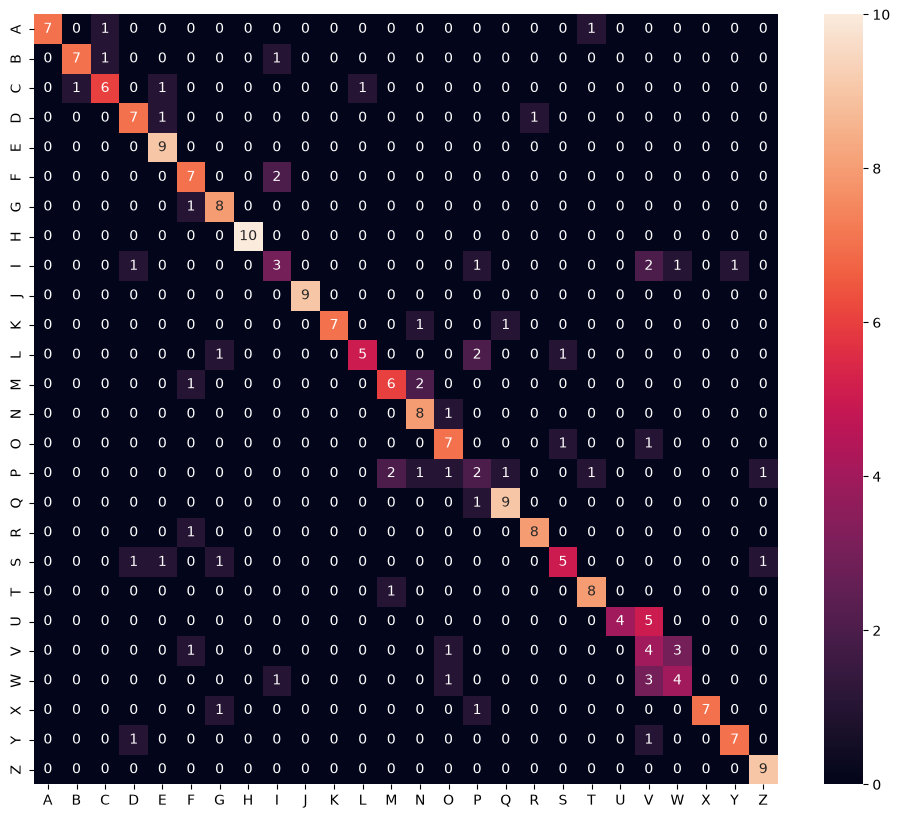

In [21]:
cm = confusion_matrix(y_test, preds)

cm_df = pd.DataFrame(
    cm,
    index=le.classes_,
    columns=le.classes_
)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,10))
sns.heatmap(cm_df, annot=True, fmt="d")
plt.show()

In [36]:
## from hyperparameter tuning (later)

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

rf = RandomForestClassifier(
    random_state=42,
    n_estimators=1500,
    criterion="entropy",
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features="log2",
    n_jobs=-1
)

rf.fit(X_train, y_train)

preds = rf.predict(X_test)

acc = accuracy_score(y_test, preds)

print(acc)

0.7966101694915254


FEATURE SELECTION USING FEATURE IMPORTANCE(RANDOM FOREST)

In [22]:
importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf.feature_importances_
})

importance_df = importance_df.sort_values(
    by='importance',

    ascending=False
)

print(importance_df.to_string(index=False))

                 feature  importance
      global_gyro_x_mean    0.006341
     global_emg7_std_dev    0.005713
     global_emg1_std_dev    0.005604
    segment1_gyro_x_mean    0.005555
     global_emg7_tot_eng    0.005457
     global_emg1_tot_eng    0.005047
     global_emg2_std_dev    0.004828
       global_gyro_x_max    0.004644
     global_emg2_tot_eng    0.004638
 segment2_gyro_x_tot_eng    0.003983
   segment2_emg7_std_dev    0.003926
     global_emg6_std_dev    0.003897
      global_yaw_std_dev    0.003805
   segment3_emg7_std_dev    0.003769
    segment2_gyro_x_mean    0.003724
   segment5_emg7_std_dev    0.003717
     global_emg3_std_dev    0.003702
   segment2_emg7_tot_eng    0.003691
   global_gyro_x_tot_eng    0.003625
     global_emg8_std_dev    0.003606
 segment3_gyro_y_std_dev    0.003547
   segment4_emg7_tot_eng    0.003449
   segment4_emg7_std_dev    0.003443
   global_gyro_x_std_dev    0.003416
   segment2_emg2_tot_eng    0.003408
       global_gyro_z_max    0.003385
 

USING THE FIRST HALF OF THE MOST IMPORTANT FEATURE IN THE NEXT ITERATION OF THE RANDOM FOREST



In [24]:
rf2 = RandomForestClassifier(
    random_state=42,
    n_estimators=1000,
    criterion="gini",
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features="sqrt",
    bootstrap=True,
    n_jobs=-1
)
selector = SelectFromModel(
    rf,
    threshold='median',
    prefit=True
)
X_train_sel = selector.transform(X_train)
X_test_sel = selector.transform(X_test)

rf2.fit(X_train_sel, y_train)

preds2 = rf2.predict(X_test_sel)

acc2 = accuracy_score(y_test, preds2)

print(f"Accuracy: {acc2:.4f}")

c:\Users\Deydeepya\Desktop\github\SignLink\sign_lang_classification\venv\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(
c:\Users\Deydeepya\Desktop\github\SignLink\sign_lang_classification\venv\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(


Accuracy: 0.7542


In [25]:
print("accuracy",acc2)
print(classification_report(
    le.inverse_transform(y_test),
    le.inverse_transform(preds2)
))

accuracy 0.7542372881355932
              precision    recall  f1-score   support

           A       1.00      0.78      0.88         9
           B       1.00      0.78      0.88         9
           C       0.78      0.78      0.78         9
           D       0.80      0.89      0.84         9
           E       0.90      1.00      0.95         9
           F       0.71      0.56      0.62         9
           G       0.80      0.89      0.84         9
           H       1.00      1.00      1.00        10
           I       0.62      0.56      0.59         9
           J       1.00      1.00      1.00         9
           K       0.86      0.67      0.75         9
           L       0.50      0.56      0.53         9
           M       0.60      0.67      0.63         9
           N       0.64      0.78      0.70         9
           O       0.64      0.78      0.70         9
           P       0.43      0.33      0.38         9
           Q       0.82      0.90      0.86        10

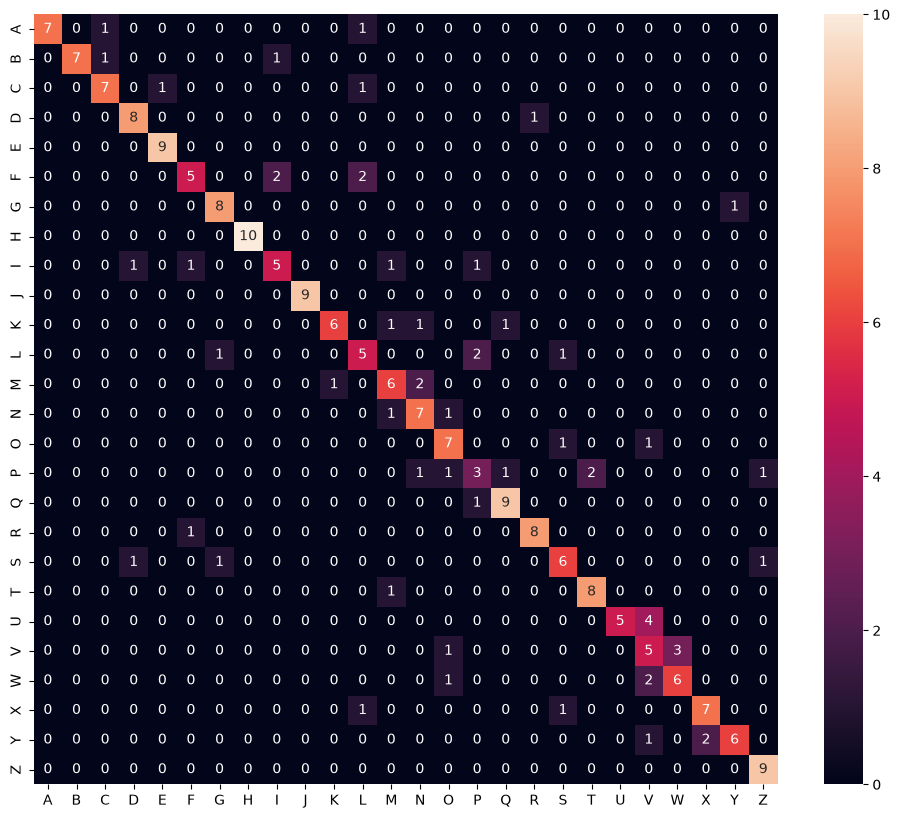

In [26]:
cm1 = confusion_matrix(y_test, preds2)

cm_df = pd.DataFrame(
    cm1,
    index=le.classes_,
    columns=le.classes_
)

plt.figure(figsize=(12,10))
sns.heatmap(cm_df, annot=True, fmt="d")
plt.show()

HYPERPARAMETER TRAINING AND K-FOLD TESTING

In [27]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import StratifiedKFold

from scipy.stats import randint, uniform

# Define the parameter distributions to sample from
param_distributions = {
    'n_estimators': [300,500,800,1000,1500],
    'criterion': ['gini','entropy'],
    'max_depth': [None,20,30,40],
    'min_samples_split': [2,3,5,8,10],
    'min_samples_leaf': [1,2,3,5],
    'max_features': ['sqrt','log2']
}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Initialize the RandomizedSearchCV object
# We use the rf2 model as the estimator
random_search = RandomizedSearchCV(
    estimator=rf2,
    param_distributions=param_distributions,
    n_iter=100, 
    cv=cv,      
    n_jobs=-1, 
    verbose=2, 
    random_state=42, 
    scoring='accuracy' 
)

# Fit the random search to the data
print("Starting Randomized Search for optimal hyperparameters...")
random_search.fit(X_train_sel, y_train)
print("Randomized Search complete.")

# Print the best parameters and the best score
print(f"Best parameters found: {random_search.best_params_}")
print(f"Best cross-validation accuracy: {random_search.best_score_:.4f}")

# You can access the best model directly
best_rf2_model_random = random_search.best_estimator_

# Evaluate the best model on the test set
best_preds_random = best_rf2_model_random.predict(X_test_sel)
best_acc_random = accuracy_score(y_test, best_preds_random)
print(f"Test accuracy with best parameters from Randomized Search: {best_acc_random:.4f}")

Starting Randomized Search for optimal hyperparameters...
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Randomized Search complete.
Best parameters found: {'n_estimators': 1500, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': None, 'criterion': 'entropy'}
Best cross-validation accuracy: 0.7717
Test accuracy with best parameters from Randomized Search: 0.8347


In [28]:
cv_results = pd.DataFrame(random_search.cv_results_)
cv_results[["mean_test_score", "std_test_score"]].sort_values(
    "mean_test_score", ascending=False
).head()

,mean_test_score,std_test_score
17,0.771744,0.018310
11,0.769622,0.015474
85,0.769622,0.015474
81,0.759000,0.024143
41,0.743088,0.030294


In [30]:
rf3 = RandomForestClassifier(
    random_state=42,
    n_estimators=1500,
    criterion="entropy",
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features="log2",
    bootstrap=True,
    n_jobs=-1
)
selector = SelectFromModel(
    rf,
    threshold='median',
    prefit=True
)
X_train_sel = selector.transform(X_train)
X_test_sel = selector.transform(X_test)

rf3.fit(X_train_sel, y_train)

preds3 = rf3.predict(X_test_sel)

acc3 = accuracy_score(y_test, preds3)

print(f"Accuracy: {acc3:.4f}")

c:\Users\Deydeepya\Desktop\github\SignLink\sign_lang_classification\venv\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(
c:\Users\Deydeepya\Desktop\github\SignLink\sign_lang_classification\venv\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(


Accuracy: 0.8347


### HYPERPARAMETER ACCROSS DIFFERENT RANDOM STATES

In [31]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import accuracy_score
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, train_test_split

# Define the seeds
seeds = [
    1,
    42,
    67,
    69,
    203,
    404,
    505,
    777,
    999,
    2025,
    3000,
    5000,
    6000,
    7000,
    8000,
    9000,
    10000,
]

# Define the parameter distributions to sample from for RandomizedSearch
param_distributions = {
    "n_estimators": [300, 500, 800, 1000, 1500],
    "criterion": ["gini", "entropy"],
    "max_depth": [None, 20, 30, 40],
    "min_samples_split": [2, 3, 5, 8, 10],
    "min_samples_leaf": [1, 2, 3, 5],
    "max_features": ["sqrt", "log2"],
}

# Lists to store accuracies for final statistics
rf1_accuracies = []
rf2_accuracies = []
rf2_tuned_accuracies = []
cv_scores = []

print("Running iterations over seeds...\n")
print(
    f"{'Seed':<8} | {'RF1 Accuracy':<14} | {'RF2 Accuracy':<14} | {'RF2 Tuned Acc':<14} | {'Best CV Score':<14}"
)
print("-" * 82)

for seed in seeds:
    # 1. Train/Test Split (Only changing this random_state)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=seed
    )

    # 2. First Random Forest Model
    rf = RandomForestClassifier(
        random_state=42,
        n_estimators=1000,
        criterion="gini",
        max_depth=None,
        min_samples_split=5,
        min_samples_leaf=2,
        max_features="sqrt",
        bootstrap=True,
        n_jobs=-1,
    )

    rf.fit(X_train, y_train)
    preds = rf.predict(X_test)
    acc = accuracy_score(y_test, preds)
    rf1_accuracies.append(acc)

    # 3. Feature Selection & Second Random Forest Model
    rf2 = RandomForestClassifier(
        random_state=42,
        n_estimators=1000,
        criterion="gini",
        max_depth=None,
        min_samples_split=5,
        min_samples_leaf=2,
        max_features="sqrt",
        bootstrap=True,
        n_jobs=-1,
    )

    selector = SelectFromModel(rf, threshold="median", prefit=True)
    X_train_sel = selector.transform(X_train)
    X_test_sel = selector.transform(X_test)

    rf2.fit(X_train_sel, y_train)
    preds2 = rf2.predict(X_test_sel)
    acc2 = accuracy_score(y_test, preds2)
    rf2_accuracies.append(acc2)

    # 4. Hyperparameter Tuning on RF2 via RandomizedSearchCV
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    random_search = RandomizedSearchCV(
        estimator=rf2,
        param_distributions=param_distributions,
        n_iter=100,
        cv=cv,
        n_jobs=-1,
        verbose=0,  # Turned verbose down to 0 to keep the loop table readable
        random_state=42,
        scoring="accuracy",
    )

    random_search.fit(X_train_sel, y_train)

    # Evaluate the best randomized search model on the test set
    best_rf2_model_random = random_search.best_estimator_
    best_preds_random = best_rf2_model_random.predict(X_test_sel)
    best_acc_random = accuracy_score(y_test, best_preds_random)
    rf2_tuned_accuracies.append(best_acc_random)
    best_cv_score = random_search.best_score_
    cv_scores.append(best_cv_score)

    # Print individual results for the current seed
    print(f"{seed:<8} | {acc:<14.4f} | {acc2:<14.4f} | {best_acc_random:<14.4f} | {best_cv_score:<14.4f}")

print("-" * 82)

# 5. Calculate and display Mean and Standard Deviation
print(
    f"\n{'Metric':<10} | {'RF1 Model':<14} | {'RF2 Model':<14} | {'RF2 Tuned':<14} | {'Best CV Score':<14}"
)
print("-" * 82)
print(
    f"{'Mean':<10} | {np.mean(rf1_accuracies):<14.4f} | {np.mean(rf2_accuracies):<14.4f} | {np.mean(rf2_tuned_accuracies):<14.4f} | {np.mean(cv_scores):<14.4f}"
)
print(
    f"{'Std Dev':<10} | {np.std(rf1_accuracies):<14.4f} | {np.std(rf2_accuracies):<14.4f} | {np.std(rf2_tuned_accuracies):<14.4f} | {np.std(cv_scores):<14.4f}"
)

Running iterations over seeds...

Seed     | RF1 Accuracy   | RF2 Accuracy   | RF2 Tuned Acc  | Best CV Score 
----------------------------------------------------------------------------------


c:\Users\Deydeepya\Desktop\github\SignLink\sign_lang_classification\venv\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(
c:\Users\Deydeepya\Desktop\github\SignLink\sign_lang_classification\venv\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(


KeyboardInterrupt: 

---
## Extra Trees Model

In [34]:
xt1= ExtraTreesClassifier(
    random_state=42,
    n_estimators=1500,
    criterion="entropy",
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features="log2",
    bootstrap=True,
    n_jobs=-1
)     

selector = SelectFromModel(
    rf,
    threshold='median',
    prefit=True
)
X_train_sel = selector.transform(X_train)
X_test_sel = selector.transform(X_test)

xt1.fit(X_train_sel, y_train)

preds4 = xt1.predict(X_test_sel)

acc4 = accuracy_score(y_test, preds4)

print(f"Accuracy: {acc4:.4f}")

c:\Users\Deydeepya\Desktop\github\SignLink\sign_lang_classification\venv\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(
c:\Users\Deydeepya\Desktop\github\SignLink\sign_lang_classification\venv\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(


Accuracy: 0.8390
